In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

In [85]:
df = pd.read_csv('../eda-project-real-estate/KC_housing_data.csv')

print(df.eq(0).sum())

date                0
price              49
bedrooms            2
bathrooms           2
sqft_living         0
sqft_lot            0
floors              0
waterfront       4567
view             4140
condition           0
sqft_above          0
sqft_basement    2745
yr_built            0
yr_renovated     2735
street              0
city                0
statezip            0
country             0
dtype: int64


In [86]:
df = df[df['price'] != 0]
df = df[df['bedrooms'] != 0]
df = df[df['bathrooms'] != 0]

print(df.eq(0).sum())

date                0
price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       4519
view             4102
condition           0
sqft_above          0
sqft_basement    2716
yr_built            0
yr_renovated     2706
street              0
city                0
statezip            0
country             0
dtype: int64


## Task 1 Linear Regression: Predicting House Prices
- Load the housing dataset.
- Visualize key features vs target price.
- Split data into train and test sets.
- Fit a Linear Regression model to predict house prices.
- Predict on test data and compute Mean Squared Error (MSE).
- Plot true vs predicted house prices.
- Interpret what the MSE says about model accuracy.

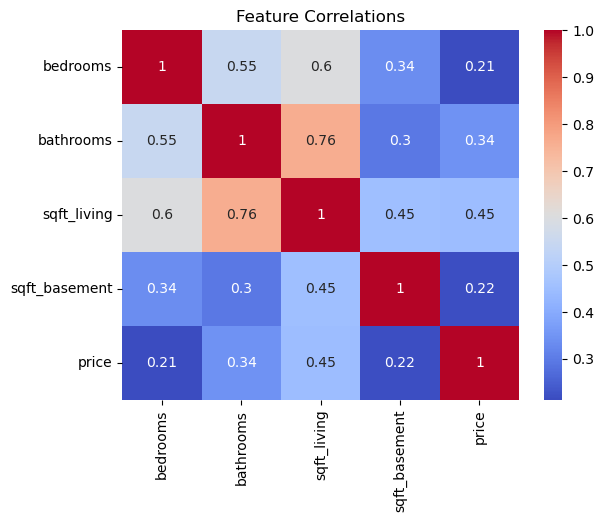

In [ ]:
# 1. Key Features vs Target Price
key_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_basement']

corr = df[key_features + ['price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

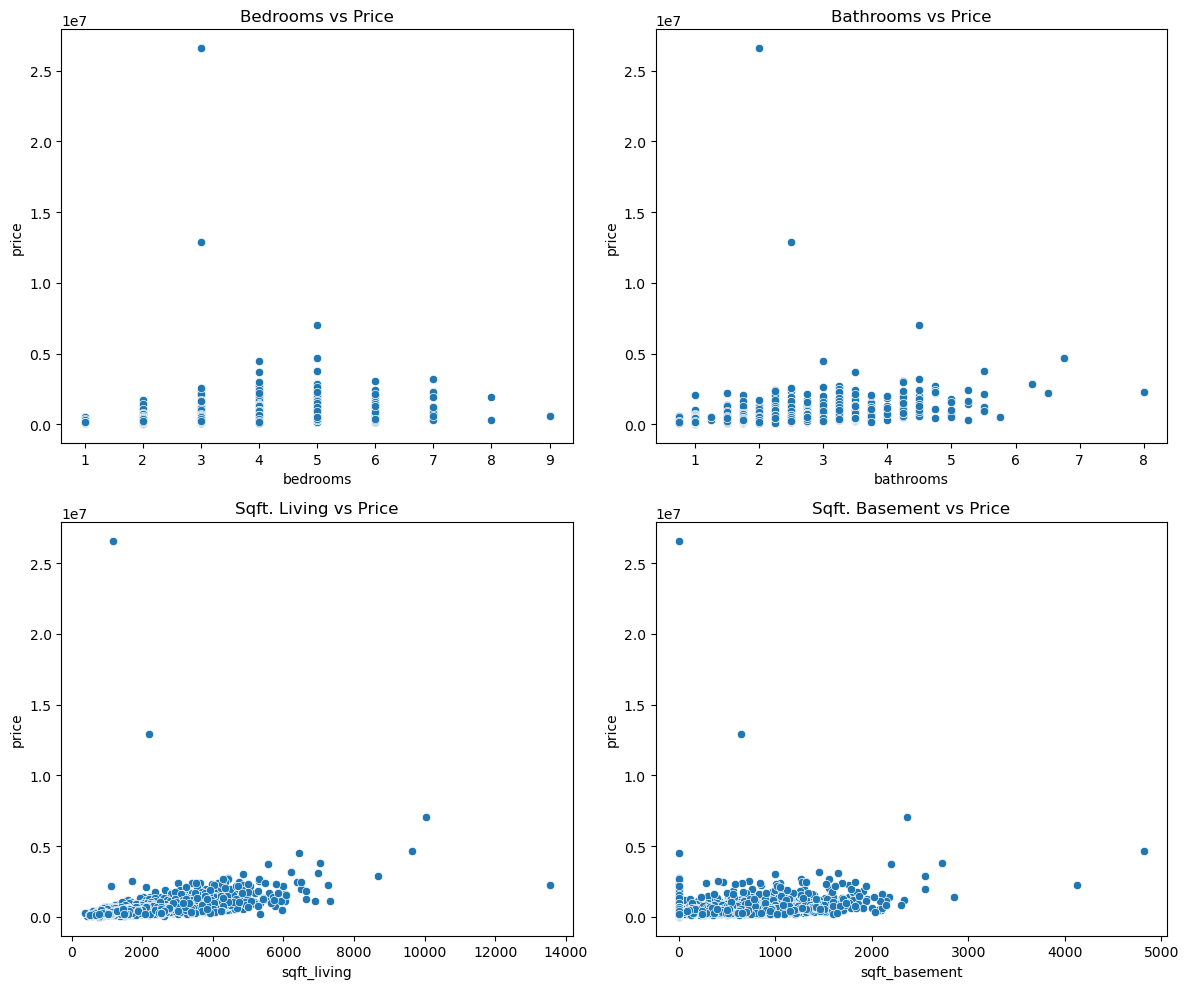

In [88]:
fig, ax = plt.subplots(2, 2, figsize=(12,10))

sns.scatterplot(data=df, x='bedrooms', y='price', ax=ax[0,0])
ax[0,0].set_title('Bedrooms vs Price')

sns.scatterplot(data=df, x='bathrooms', y='price', ax=ax[0,1])
ax[0,1].set_title('Bathrooms vs Price')

sns.scatterplot(data=df, x='sqft_living', y='price', ax=ax[1,0])
ax[1,0].set_title('Sqft. Living vs Price')

sns.scatterplot(data=df, x='sqft_basement', y='price', ax=ax[1,1])
ax[1,1].set_title('Sqft. Basement vs Price')

plt.tight_layout()
plt.show()

In [89]:
# 2. Train and test data sets
X = df[['sqft_living']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# 3. Fit a linear regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# 4. Predict on test data and compute Mean Squared Error (MSE)
lin_pred = lin_model.predict(X_test);

mse = mean_squared_error(y_test, lin_pred)
print("Linear Regression mean squared error:", mean_squared_error(y_test, lin_pred))

Linear Regression mean squared error: 85209142454.7636


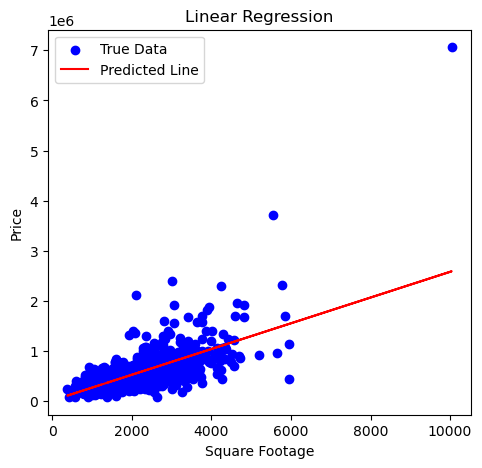

In [90]:
# 5. Plot true vs predicted house prices
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_test, y_test, color='blue', label='True Data')
plt.plot(X_test, lin_pred, color='red', label='Predicted Line')
plt.title('Linear Regression')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.legend()

The MSE represents the model's precision.\
The MSE's value is relatively high due to some outliers we see in the graph, therefore indicating that the model is not the best fit. \
To fully capture the market's complexity, we might need a multi-feature model.

## Tasks 2 Logistic Regression: Classifying Expensive Houses
- Create a new binary target variable:
    - 1 if house price is above median price, else 0.
- Split data into train and test sets.
- Fit a Logistic Regression model to predict this binary label.
- Predict on test data and compute classification accuracy.
- Visualize confusion matrix or ROC curve.
- Discuss when logistic regression is useful compared to linear.

In [91]:
# 1. New binary target 
y_binary = (y > y.median()).astype(int)

# 2. Split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=42)


# 3. Logistic Regression model
log_model = LogisticRegression()
log_model.fit(X_train_b, y_train_b)

# 4. Predict and Evaluate
log_pred = log_model.predict(X_test_b)

print("Logistic Regression accuracy:", accuracy_score(y_test_b, log_pred))

Logistic Regression accuracy: 0.7450549450549451


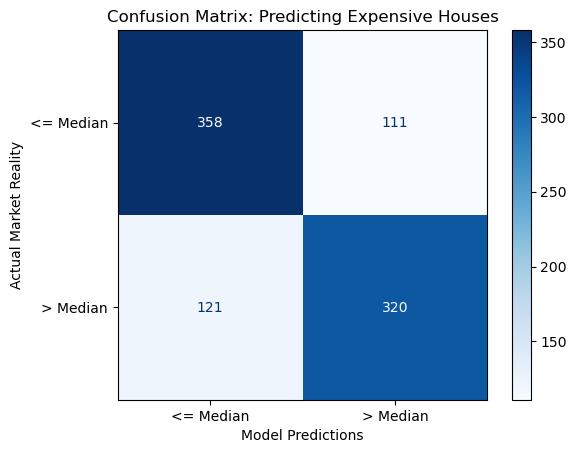

In [92]:
# 5. Visualize confusion matrix.
cm = confusion_matrix(y_test_b, log_pred)

# 2. Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<= Median', '> Median'])
disp.plot(cmap='Blues')
plt.xlabel('Model Predictions')
plt.ylabel('Actual Market Reality')
plt.title('Confusion Matrix: Predicting Expensive Houses')
plt.show()

**Top-left (true negatives):** houses that are below median price and the model predicted correctly. \
**Bottom-right (true positives):** houses that are above median price and the model predicted correctly. \
**Top-right (false positives):** houses that are cheap but the model predicted they were expensive. \
**Bottom-left (false negatives):** houses that are expensive but the model predicted they were cheap.

## Task 3: Comparison and Reflection
- Summarize differences in outputs, tasks, and metrics of the two models.
- Discuss real-world use cases for predicting prices vs classifying expensive houses.
- Optionally, experiment with features and see how adding/removing features affects both models.

### Outputs

Linear regression ouputs a specific number (cost). \
Logic regression outputs a probability between 0 and 1.

### Tasks

For linear regression, we predict a continuous number (house price). \
For logic regression, we predict a category ('is it above the mean' / 'is it expensive?')

###  Metrics

Linear regression uses distance metrics to verify how far off the price was. \
Logic regression uses accuracy, confusion matrices (and roc curves) to verify how often the model guessed the correct the c orrect category.